<a href="https://colab.research.google.com/github/selcannatakk/selcanatakai-code/blob/main/GPT_decoder_only.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Sıfırdan GPT Model Eğitimi (Decoder-Only Transformer)

Bu projede:
- Türkçe veri ile model eğitiyoruz
- Kendi tokenizer'ımızı yazıyoruz
- Transformer mantığını sıfırdan kuruyoruz
- Modelden metin üretiyoruz

💡 Amaç: GPT’nin nasıl çalıştığını gerçekten anlamak

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import torch
print(torch.cuda.is_available())

True


## 📊 Veri Hazırlama

Modelin öğrenebilmesi için büyük miktarda metne ihtiyacı vardır.

Bu projede:
- Türkçe Wikipedia verisini kullanıyoruz
- Metinleri birleştirerek tek bir corpus oluşturuyoruz

📌 Pipeline:
Text Data → Temizleme → Model Input

In [ ]:
import requests

#Data loads
# - 1

# url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
# text = requests.get(url).text


# - 2, file
# with open(input_file, 'r', encoding='utf-8') as f:
#     text = f.read()

#- 3
from datasets import load_dataset

dataset = load_dataset(
    "wikimedia/wikipedia",
    "20231101.tr",
    split="train[:1%]"
)

texts = dataset["text"]

text = " ".join(texts)

print(len(text))
print(text[:500])

README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

20231101.tr/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  340MB            

20231101.tr/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

20231101.tr/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  213MB            

20231101.tr/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/534988 [00:00<?, ? examples/s]

40402663
Cengiz Han (doğum adıyla Temuçin,  – 18 Ağustos 1227), Moğol İmparatorluğu'nun kurucusu ve ilk Kağanı olan Moğol komutan ve hükümdardır. Hükümdarlığı döneminde gerçekleştirdiği hiçbir savaşı kaybetmeyen Cengiz Han, dünya tarihinin en büyük askeri liderlerinden birisi olarak kabul edilmektedir. 13. yüzyılın başında Orta Asya'daki tüm göçebe bozkır kavimlerini birleştirip bir ulus hâline getirerek Moğol siyasi kimliği çatısı altında toplamıştır. Cengiz Han, hükümdarlığı döneminde, 1206-1227 arasın


## 🔤 Tokenization (Karakter Bazlı)

GPT aslında metni doğrudan anlamaz.  
Onu sayılara çeviririz.

Bu projede:
- Character-level tokenizer kullanıyoruz
- Her karakter bir sayıya karşılık gelir

### Örnek:
"merhaba" → [12, 5, 8, 1, 3, 1, 9]

📌 Neden character-level?
- Basit
- Küçük dataset için uygun
- Mantığı anlamak için ideal

In [ ]:
#Character-level tokenizer: karakter pattern öğrenme

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(l):
    return ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)

In [ ]:
a = encode("selcanatak")

In [ ]:
print(decode(a))

selcanatak


## 📊 Train / Validation / Test

Veriyi 3'e bölüyoruz:

- Train: Model öğrenir
- Validation: Performans kontrol edilir
- Test: Final değerlendirme

📌 Neden önemli?
Modelin ezberlemesini engeller

In [ ]:
n = len(data)

train_size = int(0.8 * n)
val_size = int(0.1 * n)

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

print(len(train_data), len(val_data), len(test_data))



32322130 4040266 4040267


## 🔁 Batch Mantığı

Model tek tek değil, batch halinde öğrenir.

Her batch'te:
- Input: karakter dizisi
- Target: bir sonraki karakter

### Örnek:
Input  → "selc"  
Target → "elca"

📌 Amaç:
Model bir sonraki karakteri tahmin etmeyi öğrenir

In [ ]:
def get_batch(split):
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# Hyperparameters
batch_size = 64
block_size = 128
max_iters = 2000
eval_interval = 200
learning_rate = 3e-4
n_embd = 256
n_head = 8
n_layer = 4
dropout = 0.2
eval_iters = 200

In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

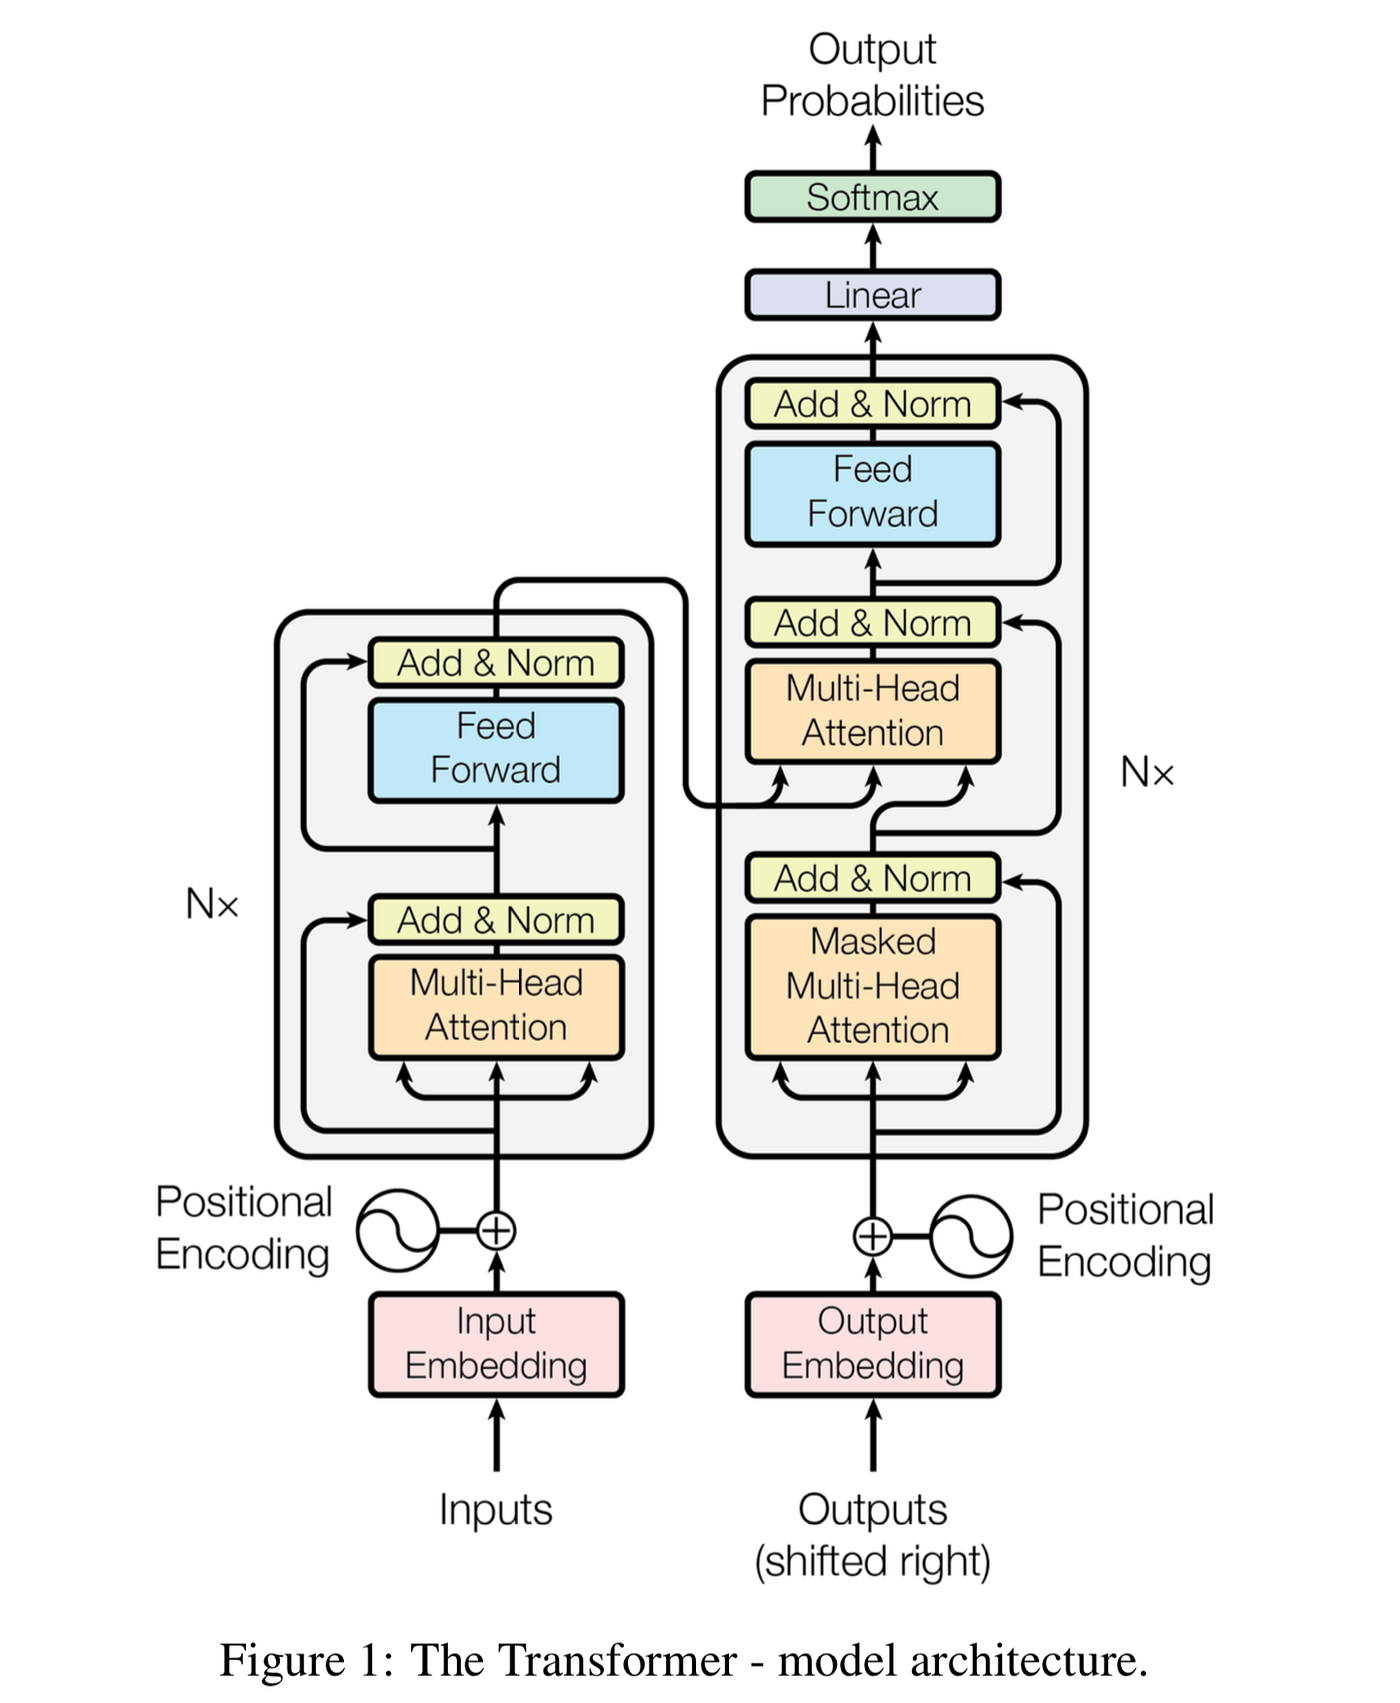

## 🤯 Transformer (Self-Attention)

Bu modelin kalbi burasıdır.

Model:
- Kelimelerin birbirleriyle ilişkisini öğrenir
- Hangi kelime önemli onu belirler

### Self-Attention Mantığı:

"Ben bugün okula gittim"

Model şunu öğrenir:
- "gittim" → "okula" ile ilişkili
- "bugün" → zaman bilgisi

📌 Özet:
Her kelime diğerlerine bakar ve önem skorları oluşturur

## 🧩 Model Yapısı

Model şu parçalardan oluşur:

1. Token Embedding
2. Positional Encoding
3. Transformer Blocks
4. Linear Layer (çıktı)

📌 Pipeline:

Token → Embedding → Transformer → Output

In [ ]:
# Decoder-only Transformer
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2,-1) * C**-0.5
        wei = wei.masked_fill(self.tril[:T,:T]==0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v

class MultiHeadAttention(nn.Module):
    def __init__(self):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([Head(head_size) for _ in range(n_head)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),
            nn.ReLU(),
            nn.Linear(4*n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.sa = MultiHeadAttention()
        self.ffwd = FeedForward()
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B,T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, vocab_size),
                targets.view(-1)
            )
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


## 🔥 Model Eğitimi

Model:
- Tahmin yapar
- Gerçek değer ile karşılaştırılır
- Hata (loss) hesaplanır
- Kendini günceller

📌 Kullanılan:
- Cross Entropy Loss
- AdamW Optimizer

## 💾 Model Kaydetme

Eğitilen model kaydedilir.

📌 Neden?
- Tekrar eğitim yapmamak için
- Daha sonra kullanabilmek için

In [ ]:
import os

model = GPT().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

save_dir = "/content/drive/MyDrive/gpt_transformer/results2"
os.makedirs(save_dir, exist_ok=True)

for iter in range(max_iters):
    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # EVALUATION
    if iter % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

        # checkpoint save (validation loss bazlı istersen burada kontrol de yapabilirsin)
        torch.save(
            model.state_dict(),
            f"{save_dir}/gpt_model_iter_{iter}.pth"
        )

    # her 1000 iter’de save
    if iter % 1000 == 0:
        torch.save(
            model.state_dict(),
            f"{save_dir}/gpt_model_checkpoint_{iter}.pth"
        )
torch.save(model.state_dict(), f"{save_dir}/gpt_model_final.pth")

step 0: train loss 7.1308, val loss 7.1243
step 200: train loss 2.6999, val loss 2.7056
step 400: train loss 2.5004, val loss 2.5173
step 600: train loss 2.3477, val loss 2.3791
step 800: train loss 2.2194, val loss 2.2548
step 1000: train loss 2.1167, val loss 2.1596
step 1200: train loss 2.0277, val loss 2.0847
step 1400: train loss 1.9532, val loss 2.0231
step 1600: train loss 1.8974, val loss 1.9626
step 1800: train loss 1.8581, val loss 1.9243


In [ ]:
!ls -lh "/content/drive/MyDrive/gpt_transformer/results"

total 88M
-rw------- 1 root root 18M Sep 10 16:06 gpt_model_checkpoint_0.pth
-rw------- 1 root root 18M Sep 10 16:06 gpt_model_iter_0.pth
-rw------- 1 root root 18M Sep 10 16:06 gpt_model_iter_200.pth
-rw------- 1 root root 18M Sep 10 16:07 gpt_model_iter_400.pth
-rw------- 1 root root 18M Sep 10 16:08 gpt_model_iter_600.pth


## 🤖 Metin Üretimi

Model artık öğrendiği pattern'lere göre metin üretir.

📌 Mantık:
- Başlangıç verilir
- Model sıradaki karakteri tahmin eder
- Bu işlem tekrar eder

💡 GPT aslında:
"Sıradaki kelimeyi tahmin eder"

In [ ]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=500)[0].tolist()))

	rı ilgiset "ve merike" bu kıral yeserl eşiklerin boynu gelenmiştir. Jağ'a müzisti Prati kontlosun'da Barfikat ölՄStang 946'den İb "Berleşmiş, Kullafya ve çok çalışıneydir atıyolarak değen tenikâyer önlice için bağlan batolor. IB ve asılırda, dil onsman dö eğ전'ler istemin bokdur dırık olarak gibi him burun türü ürev bölgeci sahimlerdindeل adrılar an farkı yaşarlaya koldu binstik olurunun oluşçuğuyla in göveyle birahalların getir.

Dahmi du dizırlı verde ruhal külür Geşhrin'de kuzey Herilgesi'nde 


In [ ]:
# model = GPT()
# model_path = f"{save_dir}/gpt_model_final.pth"
# model.load_state_dict(torch.load(model_path))
# model.to(device)
# model.eval()
context = torch.zeros((1, 1), dtype=torch.long, device=device)
out = model.generate(context, max_new_tokens=500)[0]
print(decode(out.tolist()))

	gi ili sörlermekti. 0028 yılın kapınını ve çen içinde için, sanami verilikten yayı rist anıtımana alır. Şehatire roji’'in on olarak başaа Yvaşı ve başlamı olarak rest şekilebiler kistorumiyeleri Osğal Paz böpsit ağlır.

 Zusuğus zanın füahe istifabı tarıyorundur. Bu Alessya ile ürülme yururumanın Ağura I. alaya veleri, Ayna Akpancer veya (T filsumlar eşki konunu, Esino ilatifçe ve dim (d. 1954)
 2026 - Mleti, Fanomegen, İspanyası yazarıyorcı ve Ganensa’ye olayarı için prolojiji (doğa)
 1989)
 - 


In [ ]:
prompt = "Cengiz Han doğum yılı nedir?"

# prompt'u integer id'lere çevir
context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

# cevap üret
out = model.generate(context, max_new_tokens=100)

# decode et
print(decode(out[0].tolist()))

Cengiz Han doğum yılı nedir?bi bölündü:

 195 - doğulum, kültü büm yerler akmezini Bahuluğu, Amerian'ı bir siyonu şüt yarmıştı. 
